In [85]:
import numpy as np
import matplotlib.pyplot as plt

#####################
#       EX 1        #
#####################

def build_matrix(scenario):
    P = np.zeros((76, 76))
    
    def get_index(b, w, c):
        return (b * 15) + (w * 3) + c

    for b in range(5):
        for w in range(5):
            for c in range(3):
                idx_i = get_index(b, w, c)
                
                # Battery Update
                b_next = np.clip(b + w - c, 0, 4)
                
                # Weather Update
                w_probs = np.zeros(5)
                w_probs[w] += 0.6

                if w + 1 <= 4: w_probs[w + 1] += 0.2
                else: w_probs[w - 1] += 0.2
                
                if w - 1 >= 0: w_probs[w - 1] += 0.2
                else: w_probs[w + 1] += 0.2

                # Consumption Update
                c_probs = np.zeros(5)
                c_probs[c] += 0.7

                if c + 1 <= 2: c_probs[c + 1] += 0.15
                else: c_probs[c - 1] += 0.15
                
                if c - 1 >= 0: c_probs[c - 1] += 0.15
                else: c_probs[c + 1] += 0.15

                for w_next in range(5):
                    for c_next in range(3):
                        idx_j = get_index(b_next, w_next, c_next)
                        transition_prob = w_probs[w_next] * c_probs[c_next]
                        
                        # Scenario B
                        if scenario == 1:
                            if idx_j == 0 and transition_prob > 0.10:
                                transition_prob -= 0.10
                                P[idx_i, 75] += 0.10
                        
                        # Scenario C
                        elif scenario == 2:
                            if (b_next == 0 or b_next == 4) and transition_prob > 0.05:
                                transition_prob -= 0.05
                                P[idx_i, 75] += 0.05
                        
                        P[idx_i, idx_j] += transition_prob

    P[75, 75] = 1.0
    
    return P

In [86]:
P_A = build_matrix(0)
print(f"P_A = {P_A}")

P_B = build_matrix(1)
print(f"P_B = {P_B}")

P_C = build_matrix(2)
print(f"P_C = {P_C}")

P_A = [[0.42 0.18 0.   ... 0.   0.   0.  ]
 [0.09 0.42 0.09 ... 0.   0.   0.  ]
 [0.   0.18 0.42 ... 0.   0.   0.  ]
 ...
 [0.   0.   0.   ... 0.42 0.09 0.  ]
 [0.   0.   0.   ... 0.18 0.42 0.  ]
 [0.   0.   0.   ... 0.   0.   1.  ]]
P_B = [[0.32 0.18 0.   ... 0.   0.   0.1 ]
 [0.09 0.42 0.09 ... 0.   0.   0.  ]
 [0.   0.18 0.42 ... 0.   0.   0.  ]
 ...
 [0.   0.   0.   ... 0.42 0.09 0.  ]
 [0.   0.   0.   ... 0.18 0.42 0.  ]
 [0.   0.   0.   ... 0.   0.   1.  ]]
P_C = [[0.37 0.13 0.   ... 0.   0.   0.2 ]
 [0.04 0.37 0.04 ... 0.   0.   0.3 ]
 [0.   0.13 0.37 ... 0.   0.   0.2 ]
 ...
 [0.   0.   0.   ... 0.37 0.04 0.3 ]
 [0.   0.   0.   ... 0.13 0.37 0.2 ]
 [0.   0.   0.   ... 0.   0.   1.  ]]


In [87]:
def verify_matrix(P):
    if np.any(P < 0):
        print("Error: Matrix has values < 0")
        return False

    row_sums = np.sum(P, axis=1)
    check_rows = np.isclose(row_sums, 1.0, atol=1e-12)
    rows_sum_to_1 = np.all(check_rows)

    if not rows_sum_to_1:
        invalid_indices = np.where(~check_rows)[0]
        print(f"Error: The following matrix rows don't sum to 1: {invalid_indices}")
        return False

    print("The matrix is valid!")
    return True

In [88]:
verify_matrix(P_A)
verify_matrix(P_B)
verify_matrix(P_C)

The matrix is valid!
The matrix is valid!
The matrix is valid!


True

In [89]:
#####################
#       EX 2        #
#####################

def plot_failure_probabilities(P, s0_idx, Nr=10000, Ns=40):    
    
    mu_0 = np.zeros(76)
    mu_0[s0_idx] = 1
    
    # THEORETICAL
    theoretical_probs = []
    
    # mu_t = mu_0 * P^t para cada t
    for t in range(Ns + 1):
        mu_t = mu_0 @ np.linalg.matrix_power(P, t)
        theoretical_probs.append(mu_t[75])

    # EMPIRICAL
    trajectories = np.zeros((Nr, Ns + 1), dtype=int)

    for r in range(Nr):
        current_step = s0_idx
        for t in range(Ns + 1):
            trajectories[r, t] = current_step
            current_step = np.random.choice(76, p=P[current_step])

    empirical_probs = np.mean(trajectories == 75, axis=0)
    
    # PLOT
    plt.figure(figsize=(10, 6))
    time_steps = np.arange(Ns + 1)
    
    plt.plot(time_steps, theoretical_probs, 'b-', linewidth=2, label='Theoretical Probabilities')
    plt.plot(time_steps, empirical_probs, 'ro', markersize=4, alpha=0.6, label='Empirical Fraction')
    
    plt.title(f'System Failure Probability Over Time (s0={s0_idx})')
    plt.xlabel('Time Step (t)')
    plt.ylabel('Probability of being in State 75')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.show()

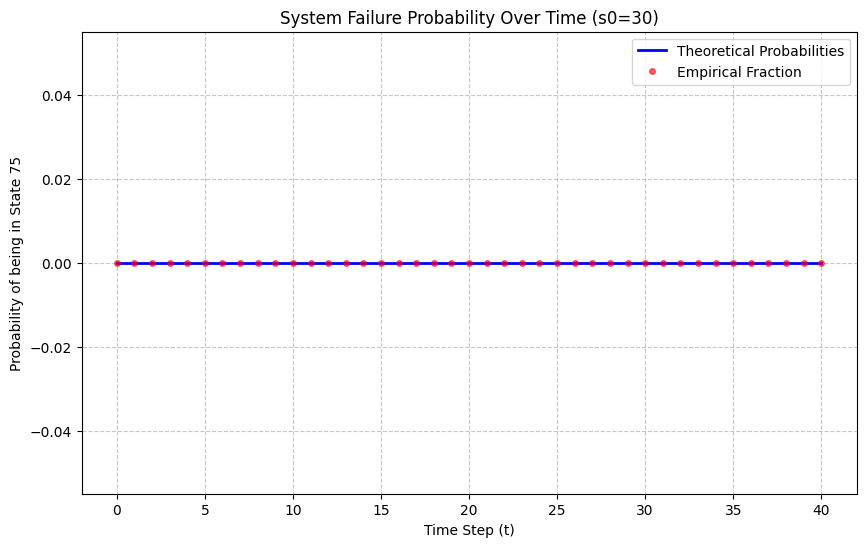

In [90]:
plot_failure_probabilities(P_A, s0_idx=30)

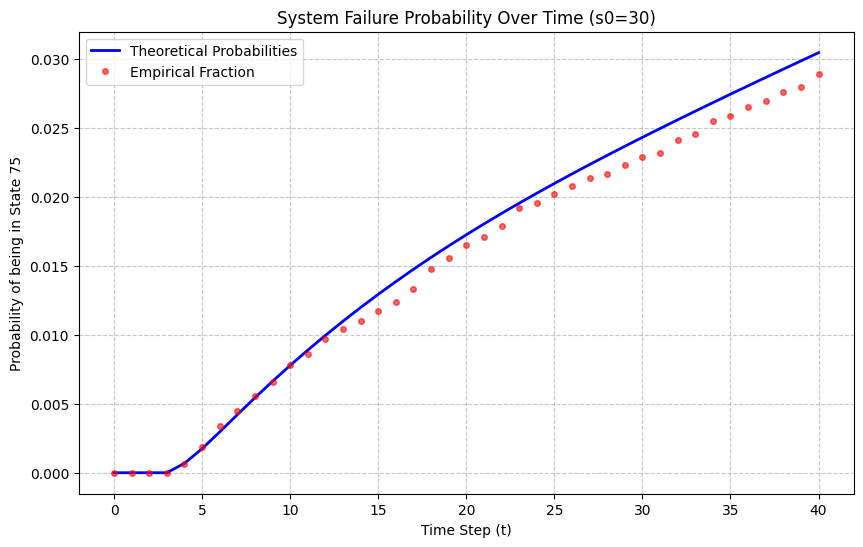

In [82]:
plot_failure_probabilities(P_B, s0_idx=30)

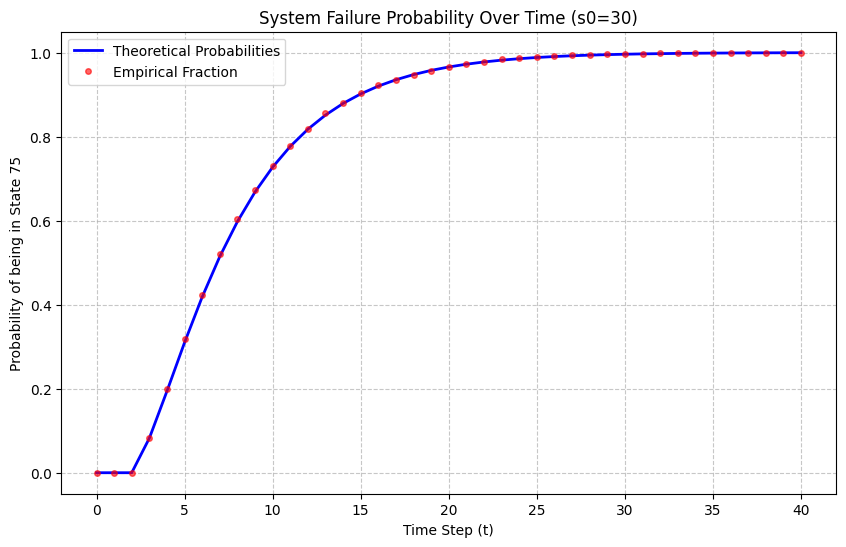

In [83]:
plot_failure_probabilities(P_C, s0_idx=30)

In [91]:
#####################
#       EX 3        #
#####################

def compute_dist_power_iteration(P, s0_idx, N=1000):
    mu = np.zeros(P.shape[0])
    mu[s0_idx] = 1.0
    
    for _ in range(N):
        mu_next = mu @ P
        mu = mu_next

    return mu

def compute_dist_eigen_decomposition(P):
    values, vectors = np.linalg.eig(P.T)

    idx = np.argmin(np.abs(values - 1.0))
    
    stationary = np.real(vectors[:, idx])
    
    stationary = stationary / np.sum(stationary)
    
    return stationary

In [92]:
N = 10000
mu_power = compute_dist_power_iteration(P_B, s0_idx=30, N=N)
mu_eigen = compute_dist_eigen_decomposition(P_B)

print(f"Distribution after {N} steps using Power Iteration: {mu_power}")
print(f"Stationary distribution using Eigen-Decomposition: {mu_eigen}")
print(f"Difference between methods = {np.linalg.norm(mu_power - mu_eigen)}")

Distribution after 10000 steps using Power Iteration: [1.56473556e-05 7.03079167e-05 5.22856151e-05 1.78296082e-05
 9.07213607e-05 7.43357898e-05 2.72325517e-06 2.28751841e-05
 2.64454617e-05 0.00000000e+00 1.58766887e-06 3.70456071e-06
 0.00000000e+00 0.00000000e+00 0.00000000e+00 8.84097335e-06
 1.75730298e-05 8.80332912e-06 1.45325553e-05 3.03265413e-05
 1.56717106e-05 5.46794937e-06 1.80035851e-05 1.01375393e-05
 6.86662577e-07 4.48025496e-06 3.66359831e-06 0.00000000e+00
 2.22405485e-07 5.18946131e-07 8.87112837e-06 1.90731357e-05
 8.01258919e-06 1.37996023e-05 3.16025364e-05 1.70468710e-05
 5.79779067e-06 1.71234809e-05 1.08896157e-05 1.06488474e-06
 4.66630899e-06 3.74847735e-06 4.76583181e-08 4.42351767e-07
 5.60866311e-07 1.04174815e-05 2.39706867e-05 9.01230978e-06
 1.54829305e-05 3.92256307e-05 2.27184941e-05 7.08497290e-06
 2.00332326e-05 1.42905103e-05 1.68343823e-06 6.20517989e-06
 4.64001482e-06 1.34487373e-07 9.46115497e-07 8.77672137e-07
 3.53516559e-05 3.25250056e-05 

In [95]:
#####################
#       EX 4        #
#####################

def compute_etf(P, s0_idx, Nr=10000, max_steps=5000):
    failure_times = []

    for r in range(Nr):
        current_state = s0_idx
        steps = 0
        
        while current_state != 75 and steps < max_steps:
            current_state = np.random.choice(76, p=P[current_state])
            steps += 1
        
        failure_times.append(steps)

    etf = np.mean(failure_times)
    standard_error = np.std(failure_times) / np.sqrt(Nr)
    
    return etf, standard_error


etf, error = compute_etf(P_C, s0_idx=30)
print(f"Expected Time to Failure (Scenario C): {etf:.2f} steps (±{error:.2f})")

Expected Time to Failure (Scenario C): 8.57 steps (±0.05)


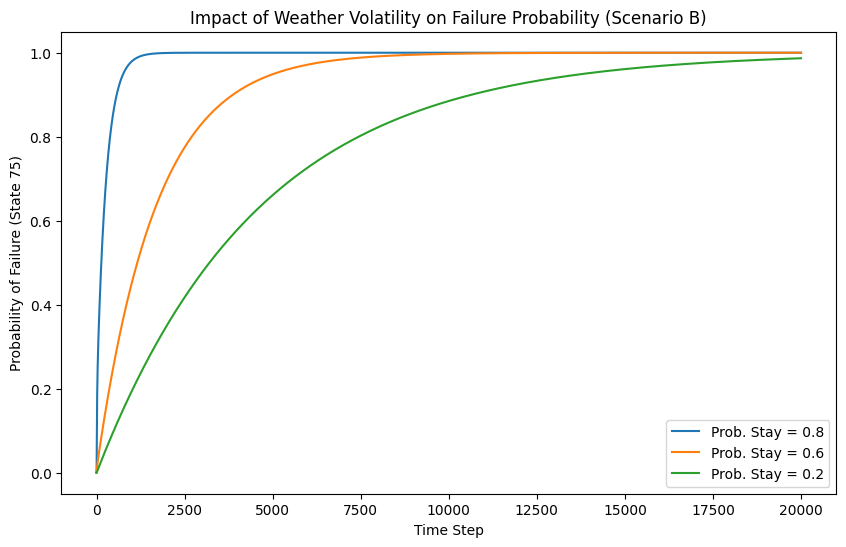

In [79]:
#####################
#       EX 5        #
#####################

def build_matrix_variable_weather(scenario, prob_stay_weather):
    P = np.zeros((76, 76))
    
    def get_index(b, w, c):
        return (b * 15) + (w * 3) + c

    for b in range(5):
        for w in range(5):
            for c in range(3):
                idx_i = get_index(b, w, c)
                
                # Battery Update
                b_next = np.clip(b + w - c, 0, 4)
                
                # Weather Update
                w_probs = np.zeros(5)
                w_probs[w] += prob_stay_weather

                if w + 1 <= 4: w_probs[w + 1] += (1-prob_stay_weather)/2
                else: w_probs[w - 1] += (1-prob_stay_weather)/2
                
                if w - 1 >= 0: w_probs[w - 1] += (1-prob_stay_weather)/2
                else: w_probs[w + 1] += (1-prob_stay_weather)/2

                # Consumption Update
                c_probs = np.zeros(5)
                c_probs[c] += 0.7

                if c + 1 <= 2: c_probs[c + 1] += 0.15
                else: c_probs[c - 1] += 0.15
                
                if c - 1 >= 0: c_probs[c - 1] += 0.15
                else: c_probs[c + 1] += 0.15

                for w_next in range(5):
                    for c_next in range(3):
                        idx_j = get_index(b_next, w_next, c_next)
                        transition_prob = w_probs[w_next] * c_probs[c_next]
                        
                        # Scenario B
                        if scenario == 1:
                            if idx_j == 0 and transition_prob > 0.10:
                                transition_prob -= 0.10
                                P[idx_i, 75] += 0.10
                        
                        # Scenario C
                        elif scenario == 2:
                            if (b_next == 0 or b_next == 4) and transition_prob > 0.05:
                                transition_prob -= 0.05
                                P[idx_i, 75] += 0.05
                        
                        P[idx_i, idx_j] += transition_prob

    P[75, 75] = 1.0
    
    return P


def analyze_volatility(volatilities=[0.8, 0.6, 0.2], s0=30):
    plt.figure(figsize=(10, 6))
    
    for p_stay in volatilities:
        P = build_matrix_variable_weather(scenario=1, prob_stay_weather=p_stay)
        
        mu_0 = np.zeros(76); mu_0[s0] = 1
        probs = []
        mu_t = mu_0.copy()
        for _ in range(20000):
            probs.append(mu_t[75])
            mu_t = mu_t @ P
            
        plt.plot(probs, label=f'Prob. Stay = {p_stay}')

    plt.title("Impact of Weather Volatility on Failure Probability (Scenario B)")
    plt.xlabel("Time Step")
    plt.ylabel("Probability of Failure (State 75)")
    plt.legend()
    plt.show()


analyze_volatility()